# GBM Survival Prediction from CyTOF Data
## Using Cellular Neighborhood-Inspired Feature Engineering

**COMP 683 — Computational Biology**   
**Dataset:** FlowRepository FR-FCM-Z24K — 28 GBM patients

---

### Pipeline Overview
1. Data Loading  
2. Preprocessing (Arcsinh transformation, patient ID normalization, clinical data merge)  
3. Cell Clustering (Leiden + Harmony batch correction, FlowSOM baseline)  
4. Feature Engineering (Cell type frequencies, Cellular Neighborhood features)  
5. Survival Prediction (Cox PH with ElasticNet, LOO-CV, Grid Search)

## 0. Import Libraries

In [1]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import fcsparser
import scanpy as sc
import anndata as ad
import harmonypy as hm

from flowsom import FlowSOM
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from itertools import product

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    integrated_brier_score,
    cumulative_dynamic_auc
)
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Data Loading

### 1.1 Verify FCS files

In [2]:
data_dir = './data/fcs_files' # your path

# List all FCS files
fcs_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.fcs')])
print(f"Number of FCS files: {len(fcs_files)}")
print("\nFirst 5 files:")
for f in fcs_files[:5]:
    print(f"  {f}")

# Inspect a single file
meta, sample = fcsparser.parse(os.path.join(data_dir, fcs_files[0]))
print(f"\nSample file: {fcs_files[0]}")
print(f"  Cells: {len(sample):,}")
print(f"  Markers: {len(sample.columns)}")
print(f"\nMarker list:\n{sample.columns.tolist()}")

Number of FCS files: 28

First 5 files:
  2017-01-17 LC10B_SIG_cells_found_normalized_Live_cells_tight_viSNE_GBM_Ungated_viSNE.fcs
  2017-01-17 LC11A_SIG_cells_found_normalized_Live_cells_tight_viSNE_GBM_Ungated_viSNE.fcs
  2017-01-17 LC12A_SIG_cells_found_normalized_Live_cells_tight_viSNE_GBM_Ungated_viSNE.fcs
  2017-01-17 W12_SIG_cells_found_normalized_Live_cells_tight_viSNE_GBM_Ungated_viSNE.fcs
  2017-01-17 W4_SIG (2)_cells_found_normalized_Live_cells_tight_viSNE_GBM_Ungated_viSNE.fcs

Sample file: 2017-01-17 LC10B_SIG_cells_found_normalized_Live_cells_tight_viSNE_GBM_Ungated_viSNE.fcs
  Cells: 4,710
  Markers: 47

Marker list:
['Time', 'Cell_length', 'Dead-103', 'CycinB1-139', '140', 'TUJ1-141 (v) (v2)', 'cCasp3-142', 'CD117-143 (v) (v2)', 'S100B-144 (v) (v2)', 'CD31-145 (v)', 'pEGFR-146', 'gH2AX-147', 'CD34-148 (v) (v2)', 'p4EBP1-149', 'pSTAT5-150 (v) (v2)', 'BMX-151', 'pAKT-152 (v) (v2)', 'pSTAT1-153 (v) (v2)', 'CD45-154 (v)', 'CD56-155 (v) (v2)', 'pp38-156 (v) (v2)', '157', 'pS

### 1.2 Load clinical data

In [3]:
clinical = pd.read_csv(os.path.join(data_dir, 'GBM Survival Data.csv'))
clinical.columns = clinical.columns.str.strip()

print(f"Clinical data shape: {clinical.shape}")
print(f"Columns: {clinical.columns.tolist()}")
print()
# OS.Time: Overall Survival (days) | OS.Status: 1=dead, 0=censored
# PFS.Time: Progression-Free Survival (days) | PFS.Status: 1=progressed, 0=censored
clinical.head(10)

Clinical data shape: (28, 5)
Columns: ['Patient.ID', 'PFS.Time', 'OS.Time', 'OS.Status', 'PFS.Status']



,Patient.ID,PFS.Time,OS.Time,OS.Status,PFS.Status
0,LC10,117,178,1,0
1,LC11,111,411,1,1
2,LC12,606,710,1,1
3,W12,190,723,1,1
4,W4,220,456,1,1
5,W5,241,282,1,1
6,LC18,133,240,1,1
7,LC21,267,267,1,1
8,LC27,79,252,1,1
9,RT07,49,57,1,1


## 2. Preprocessing

### 2.1 Combine all FCS files

In [4]:
# Technical parameters to exclude (not biological markers)
exclude_cols = [
    'Time', 'Cell_length', 'Dead-103', '140', '157',
    'NA-191', 'NA-193', 'tSNE1', 'tSNE2', 'tSNE1_2', 'tSNE2_2', 'HH3-176'
]

all_data = []

for fname in fcs_files:
    meta, df = fcsparser.parse(os.path.join(data_dir, fname))

    # Extract patient ID: take everything before "_SIG" or " SIG", remove date prefix
    fname_clean = fname.replace('.fcs', '')
    patient_id = re.split(r'[_ ]SIG', fname_clean)[0].strip()
    patient_id = re.sub(r'^\d{4}-\d{2}-\d{2}\s+', '', patient_id)

    df = df.drop(columns=[c for c in exclude_cols if c in df.columns])
    df['patient_id'] = patient_id
    all_data.append(df)

combined = pd.concat(all_data, ignore_index=True)

print(f"Total cells: {len(combined):,}")
print(f"Number of patients: {combined['patient_id'].nunique()}")
print(f"Number of markers: {len(combined.columns) - 1}")
print(f"\nPatient list:\n{sorted(combined['patient_id'].unique())}")

Total cells: 131,880
Number of patients: 28
Number of markers: 35

Patient list:
['K01', 'LC-18', 'LC-21', 'LC-27', 'LC02AB', 'LC03A', 'LC04B', 'LC06B', 'LC08A', 'LC09A', 'LC10B', 'LC11A', 'LC12A', 'LC22', 'LC25', 'LC26', 'RT-07', 'RT-14', 'RT01B', 'RT10', 'RT15', 'W11', 'W12', 'W14', 'W15', 'W2', 'W4', 'W5']


### 2.2 Arcsinh transformation

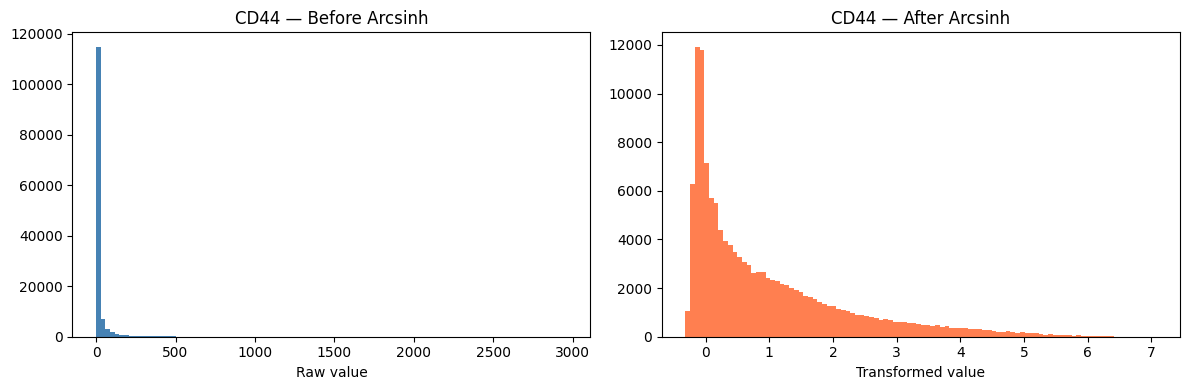

Before — min: -1.60, max: 2964.10
After  — min: -0.31, max: 7.08


In [5]:
# Arcsinh transformation with cofactor=5 (standard for CyTOF)
# Compresses large values while preserving differences near zero
cofactor = 5
marker_cols = [c for c in combined.columns if c != 'patient_id']

combined_transformed = combined.copy()
combined_transformed[marker_cols] = np.arcsinh(combined[marker_cols] / cofactor)

# Visualize transformation effect on CD44
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(combined['CD44-169 (v) (v2)'], bins=100, color='steelblue')
axes[0].set_title('CD44 — Before Arcsinh')
axes[0].set_xlabel('Raw value')
axes[1].hist(combined_transformed['CD44-169 (v) (v2)'], bins=100, color='coral')
axes[1].set_title('CD44 — After Arcsinh')
axes[1].set_xlabel('Transformed value')
plt.tight_layout()
plt.show()

print(f"Before — min: {combined['CD44-169 (v) (v2)'].min():.2f}, max: {combined['CD44-169 (v) (v2)'].max():.2f}")
print(f"After  — min: {combined_transformed['CD44-169 (v) (v2)'].min():.2f}, max: {combined_transformed['CD44-169 (v) (v2)'].max():.2f}")

### 2.3 Normalize patient IDs & merge clinical data

In [9]:
def normalize_clinical_id(pid):
    # Remove dashes: RT-07 -> RT07, LC-18 -> LC18
    return str(pid).strip().replace('-', '')

def normalize_cell_id(pid):
    # Remove dashes and trailing letters: LC10B -> LC10, LC02AB -> LC02
    pid = pid.replace('-', '')
    pid = re.sub(r'([A-Z]+\d+)[A-Z]+$', r'\1', pid)
    return pid

# Apply normalization
clinical['patient_id'] = clinical['Patient.ID'].apply(normalize_clinical_id)
combined['patient_id_norm'] = combined['patient_id'].apply(normalize_cell_id)

# Verify all patients match
cell_ids = set(combined['patient_id_norm'].unique())
clinical_ids = set(clinical['patient_id'].unique())
print(f"Matched patients: {len(cell_ids & clinical_ids)}")
print(f"Unmatched (cell data): {cell_ids - clinical_ids}")
print(f"Unmatched (clinical):  {clinical_ids - cell_ids}")

# Merge clinical data
combined = combined.merge(
    clinical[['patient_id', 'OS.Time', 'OS.Status']],
    left_on='patient_id_norm', right_on='patient_id', how='left'
)
combined = combined.drop(columns=['patient_id_y', 'patient_id_norm'])
combined = combined.rename(columns={'patient_id_x': 'patient_id'})
combined_transformed = combined.copy()
combined_transformed[marker_cols] = np.arcsinh(combined[marker_cols] / cofactor)

print(f"\nTotal cells after merge: {len(combined):,}")
print(f"Missing OS.Time: {combined['OS.Time'].isna().sum()}")
print(f"\nSurvival summary:")
print(f"  Median OS : {clinical['OS.Time'].median():.0f} days")
print(f"  Range     : {clinical['OS.Time'].min()} — {clinical['OS.Time'].max()} days")
print(f"  Deaths    : {int(clinical['OS.Status'].sum())} / {len(clinical)}")

Matched patients: 28
Unmatched (cell data): set()
Unmatched (clinical):  set()

Total cells after merge: 131,880
Missing OS.Time: 0

Survival summary:
  Median OS : 388 days
  Range     : 53 — 1588 days
  Deaths    : 26 / 28


## 3. Cell Clustering

### 3.1 Create AnnData object

In [10]:
# AnnData is the standard single-cell data format used by scanpy
# adata.X     : cell × marker expression matrix (131880 × 35)
# adata.obs   : per-cell metadata (patient_id, survival info)
# adata.var   : per-marker metadata (marker names)

marker_cols = [c for c in combined.columns
               if c not in ['patient_id', 'OS.Time', 'OS.Status']]

adata = ad.AnnData(X=combined_transformed[marker_cols].values)
adata.var_names = marker_cols
adata.obs['patient_id'] = combined_transformed['patient_id'].values
adata.obs['OS_Time']    = combined_transformed['OS.Time'].values
adata.obs['OS_Status']  = combined_transformed['OS.Status'].values

print(adata)
print(f"\nCell matrix shape: {adata.X.shape}  (cells × markers)")

AnnData object with n_obs × n_vars = 131880 × 35
    obs: 'patient_id', 'OS_Time', 'OS_Status'

Cell matrix shape: (131880, 35)  (cells × markers)


### 3.2 PCA + Initial Leiden clustering

In [11]:
# PCA: reduce 35D → 20D for computational efficiency and noise reduction
# Leiden: graph-based community detection for cell clustering
sc.pp.pca(adata, n_comps=20)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)
sc.tl.leiden(adata, resolution=0.5, random_state=42)
sc.tl.umap(adata)

print(f"Number of clusters: {adata.obs['leiden'].nunique()}")
print(f"\nCluster sizes:\n{adata.obs['leiden'].value_counts().sort_index()}")

Number of clusters: 20

Cluster sizes:
leiden
0     23353
1     22233
2     17035
3     16806
4     10148
5      8654
6      8324
7      7824
8      5099
9      4287
10     2528
11     1920
12     1233
13      915
14      596
15      444
16      326
17      118
18       26
19       11
Name: count, dtype: int64


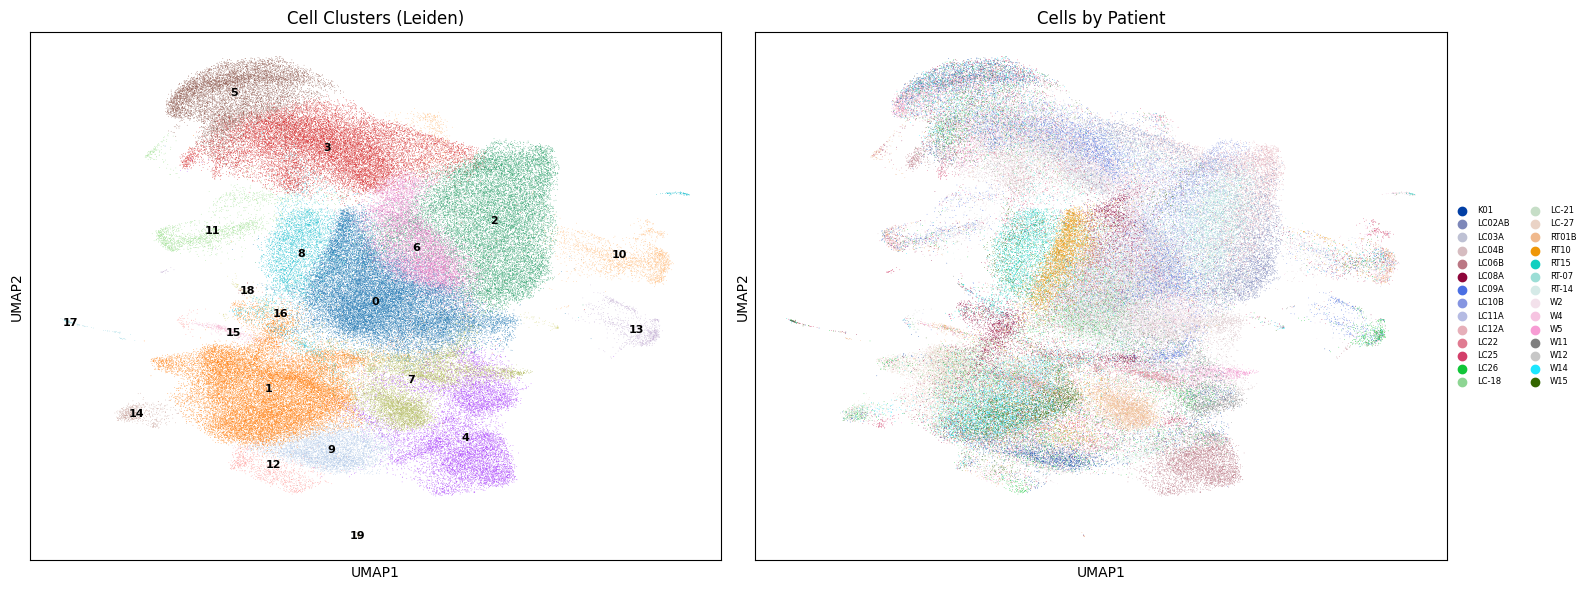

In [12]:
# Visualize: check for batch effects before correction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.umap(adata, color='leiden', ax=axes[0], show=False,
           title='Cell Clusters (Leiden)', legend_loc='on data', legend_fontsize=8)
sc.pl.umap(adata, color='patient_id', ax=axes[1], show=False,
           title='Cells by Patient', legend_loc='right margin', legend_fontsize=6)
plt.tight_layout()
plt.show()

### 3.3 Harmony batch correction

Each patient's FCS file was measured on a different date, introducing technical variation (batch effects).  
Harmony corrects this by aligning PCA embeddings across patients while preserving biological variation.

In [13]:
# Run Harmony on PCA embeddings
harmony_out = hm.run_harmony(adata.obsm['X_pca'], adata.obs, 'patient_id', max_iter_harmony=20)
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr
print(f"Harmony done. Corrected embedding shape: {adata.obsm['X_pca_harmony'].shape}")

2026-04-19 00:07:45,358 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-04-19 00:07:45,358 - harmonypy - INFO -   Parameters:
2026-04-19 00:07:45,358 - harmonypy - INFO -     max_iter_harmony: 20
2026-04-19 00:07:45,358 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-19 00:07:45,359 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-19 00:07:45,359 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-19 00:07:45,359 - harmonypy - INFO -     nclust: 100
2026-04-19 00:07:45,359 - harmonypy - INFO -     block_size: 0.05
2026-04-19 00:07:45,359 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]
2026-04-19 00:07:45,360 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2.]
2026-04-19 00:07:45,360 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-19 00:07:45,360 - harmonypy - INFO -     verbose: True
2026-04-19 00:07:45,360

Harmony done. Corrected embedding shape: (131880, 20)


In [14]:
# Re-cluster using Harmony-corrected embeddings
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca_harmony')
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_harmony', random_state=42)
sc.tl.umap(adata)

print(f"Number of clusters after correction: {adata.obs['leiden_harmony'].nunique()}")

Number of clusters after correction: 14


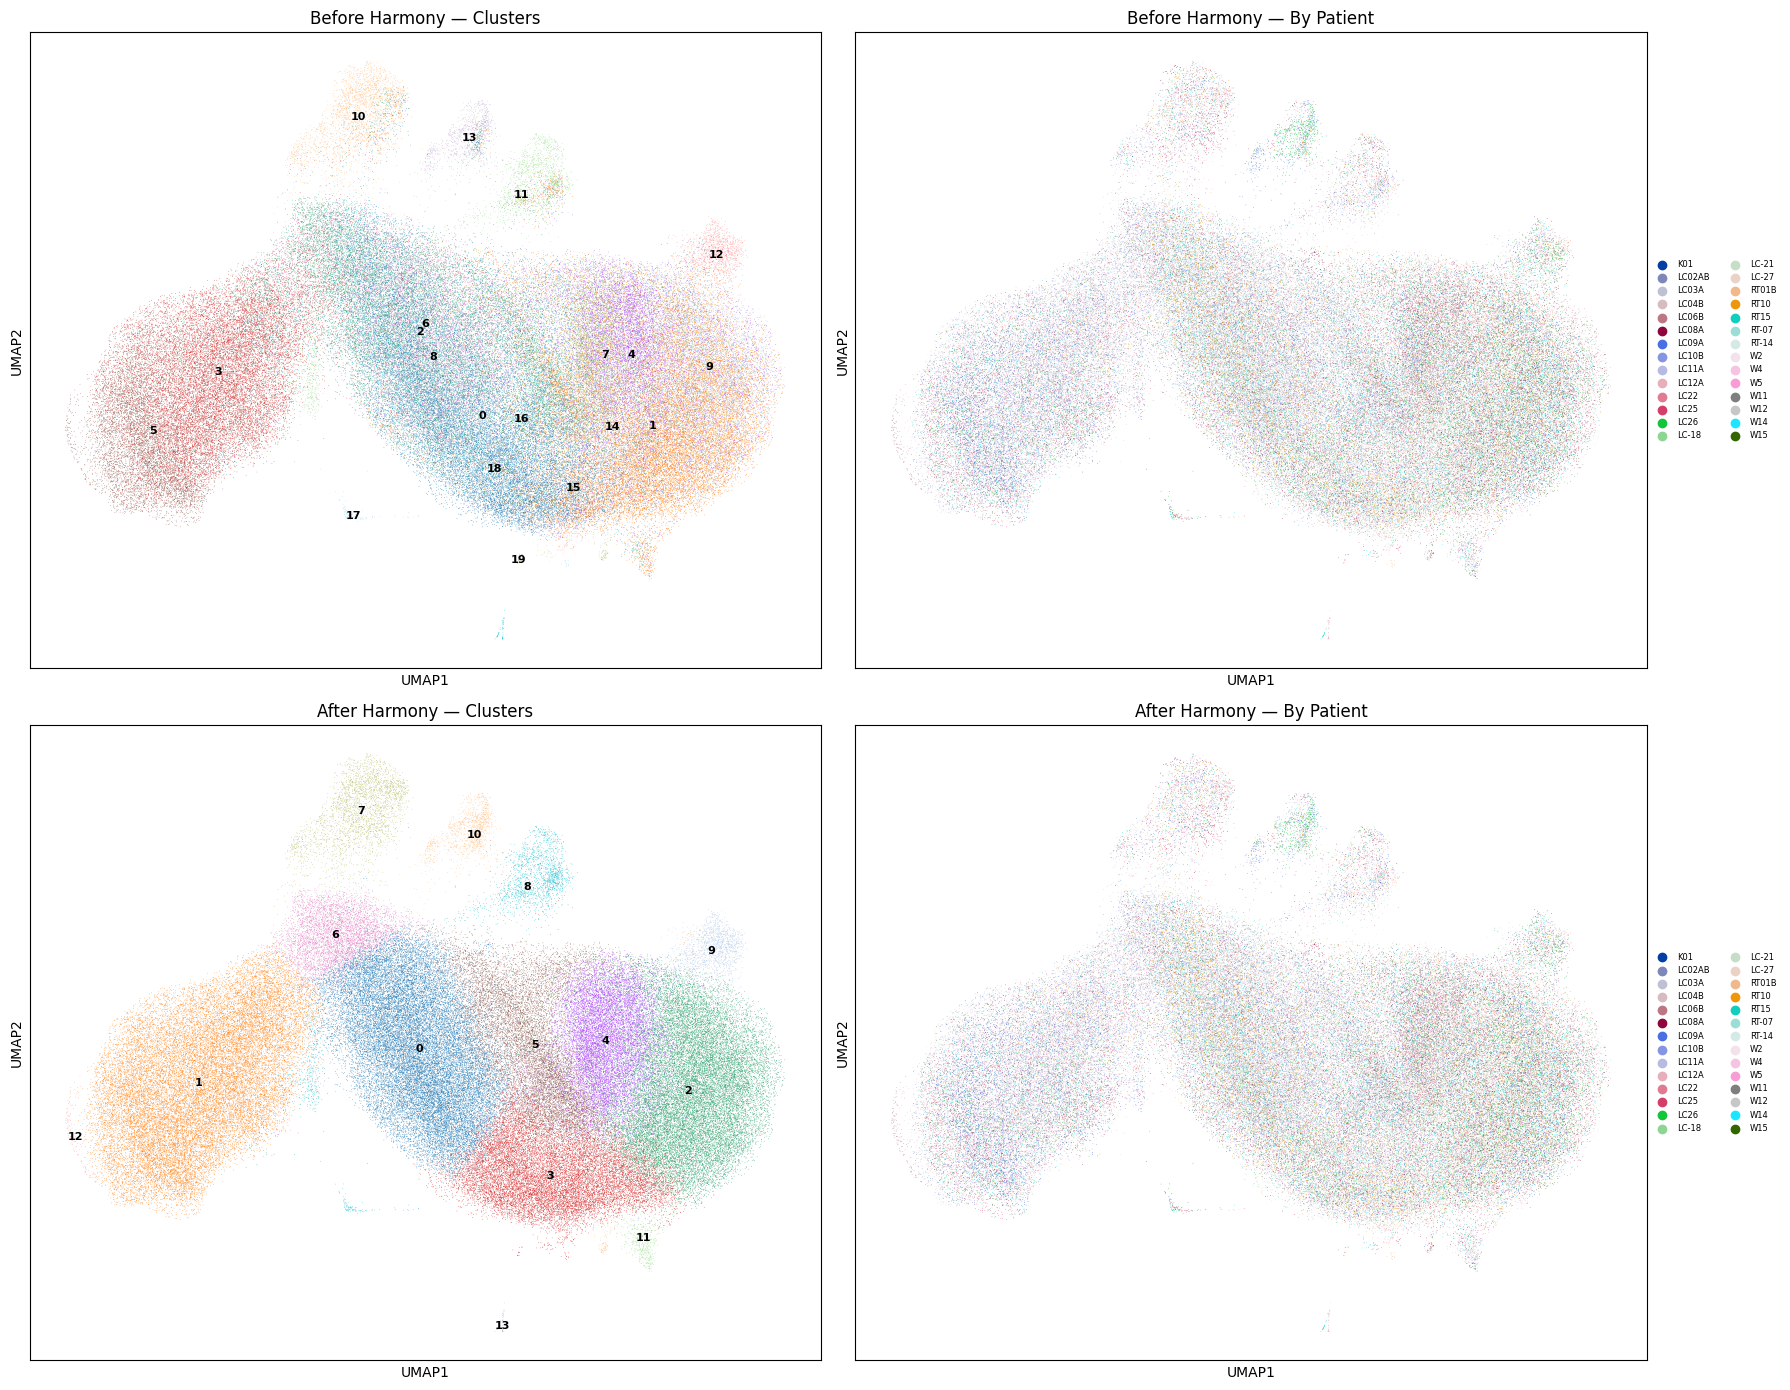

In [15]:
# Compare before and after Harmony
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
sc.pl.umap(adata, color='leiden',         ax=axes[0][0], show=False, title='Before Harmony — Clusters',   legend_loc='on data',      legend_fontsize=8)
sc.pl.umap(adata, color='patient_id',     ax=axes[0][1], show=False, title='Before Harmony — By Patient', legend_loc='right margin', legend_fontsize=6)
sc.pl.umap(adata, color='leiden_harmony', ax=axes[1][0], show=False, title='After Harmony — Clusters',    legend_loc='on data',      legend_fontsize=8)
sc.pl.umap(adata, color='patient_id',     ax=axes[1][1], show=False, title='After Harmony — By Patient',  legend_loc='right margin', legend_fontsize=6)
plt.tight_layout()
plt.show()

### 3.4 FlowSOM clustering (RAPID baseline)

FlowSOM is the clustering method used in the RAPID paper (Sinnaeve et al., eLife 2020).  
We replicate it here as a baseline to compare against our Leiden-based approach.

In [16]:
print("Running FlowSOM clustering...")

fsom = FlowSOM(
    adata.X,
    cols_to_use=list(range(adata.X.shape[1])),
    n_clusters=adata.obs['leiden_harmony'].nunique(),
    seed=42
)

flowsom_labels = fsom.metacluster_labels
adata.obs['flowsom'] = flowsom_labels.astype(str)

print(f"FlowSOM done. Number of clusters: {len(np.unique(flowsom_labels))}")
print(f"\nCluster sizes:")
for c, count in pd.Series(flowsom_labels).value_counts().sort_index().items():
    print(f"  Cluster {c}: {count:,} cells ({count/len(flowsom_labels)*100:.1f}%)")

2026-04-19 00:14:18.571 | DEBUG    | flowsom.main:__init__:82 - Reading input.
2026-04-19 00:14:18.627 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.


Running FlowSOM clustering...


2026-04-19 00:14:24.621 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.


FlowSOM done. Number of clusters: 14

Cluster sizes:
  Cluster 0: 47,028 cells (35.7%)
  Cluster 1: 5,266 cells (4.0%)
  Cluster 2: 29,778 cells (22.6%)
  Cluster 3: 7,107 cells (5.4%)
  Cluster 4: 23,907 cells (18.1%)
  Cluster 5: 9,968 cells (7.6%)
  Cluster 6: 1,310 cells (1.0%)
  Cluster 7: 733 cells (0.6%)
  Cluster 8: 1,526 cells (1.2%)
  Cluster 9: 1,138 cells (0.9%)
  Cluster 10: 2,095 cells (1.6%)
  Cluster 11: 388 cells (0.3%)
  Cluster 12: 1,071 cells (0.8%)
  Cluster 13: 565 cells (0.4%)


### 3.5 Cluster annotation heatmap

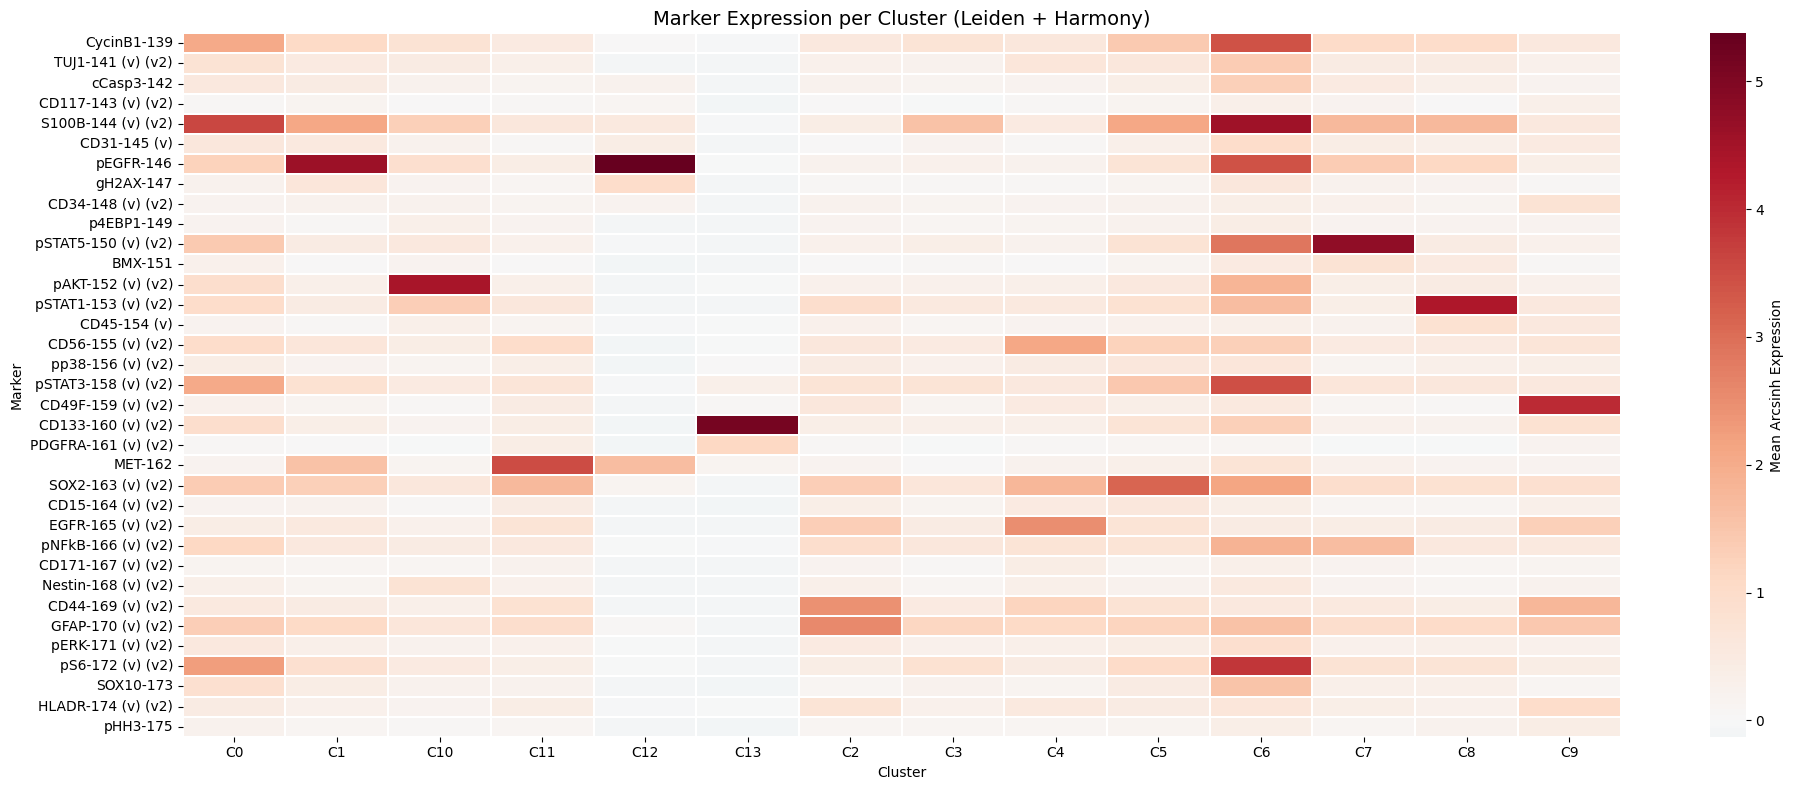

In [17]:
# Visualize mean marker expression per Leiden cluster
# Helps identify cell types: e.g. high CD45 = immune cell, high GFAP = astrocyte
adata.obs['leiden_harmony'] = adata.obs['leiden_harmony'].astype(str)
marker_df = pd.DataFrame(adata.X, columns=marker_cols)
marker_df['cluster'] = adata.obs['leiden_harmony'].values

cluster_means = marker_df.groupby('cluster')[marker_cols].mean()

plt.figure(figsize=(20, 8))
sns.heatmap(
    cluster_means.T,
    cmap='RdBu_r', center=0,
    xticklabels=[f'C{i}' for i in cluster_means.index],
    yticklabels=marker_cols,
    linewidths=0.3,
    cbar_kws={'label': 'Mean Arcsinh Expression'}
)
plt.title('Marker Expression per Cluster (Leiden + Harmony)', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Marker')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

### 4.1 Condition (a): Cell type frequencies — Leiden

RAPID baseline: represent each patient as a vector of cell cluster proportions.

In [18]:
cluster_freq = (
    combined_transformed
    .assign(cluster=adata.obs['leiden_harmony'].values)
    .groupby(['patient_id', 'cluster'])
    .size()
    .unstack(fill_value=0)
)
cluster_freq = cluster_freq.div(cluster_freq.sum(axis=1), axis=0)
cluster_freq.columns = [f'cluster_{c}_freq' for c in cluster_freq.columns]
cluster_freq.index = cluster_freq.index.map(normalize_cell_id)

print(f"Condition (a) — Leiden feature matrix: {cluster_freq.shape}")
print("(rows = patients, columns = cell type frequencies)")

Condition (a) — Leiden feature matrix: (28, 14)
(rows = patients, columns = cell type frequencies)


### 4.2 Condition (a2): Cell type frequencies — FlowSOM

Same approach as Condition (a), but using FlowSOM clusters (RAPID paper's original method).

In [19]:
adata.obs['patient_id'] = combined_transformed['patient_id'].values

flowsom_freq = (
    adata.obs[['patient_id', 'flowsom']]
    .groupby(['patient_id', 'flowsom'])
    .size()
    .unstack(fill_value=0)
)
flowsom_freq = flowsom_freq.div(flowsom_freq.sum(axis=1), axis=0)
flowsom_freq.columns = [f'flowsom_{c}_freq' for c in flowsom_freq.columns]
flowsom_freq.index = flowsom_freq.index.map(normalize_cell_id)

print(f"Condition (a2) — FlowSOM feature matrix: {flowsom_freq.shape}")

Condition (a2) — FlowSOM feature matrix: (28, 14)


### 4.3 Condition (b): Cellular Neighborhood features

**Core innovation**: define cell neighborhoods not in physical space (unavailable in CyTOF)  
but in 35D protein expression space using k-nearest neighbors.

Each cell's neighborhood profile = average marker expression of its k nearest neighbors.  
MiniBatchKMeans groups similar neighborhood profiles into Cellular Neighborhoods (CNs).

#### 4.3.1 Cox PH helper functions (used in grid search)

In [20]:
# Prepare survival data for sksurv
clinical_indexed = clinical.set_index('patient_id')

def prepare_data(feature_df):
    patients = feature_df.index.tolist()
    X = feature_df.loc[patients].values
    y = Surv.from_arrays(
        event=clinical_indexed.loc[patients, 'OS.Status'].astype(bool).values,
        time=clinical_indexed.loc[patients, 'OS.Time'].values
    )
    return X, y, patients

def run_loocv_full(feature_df, label):
    X, y, patients = prepare_data(feature_df)
    n = len(patients)
    risk_scores = np.zeros(n)

    # LOO-CV: train on n-1 patients, predict the left-out patient
    for i in range(n):
        train_idx = [j for j in range(n) if j != i]
        model = CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.1, max_iter=10000)
        model.fit(X[train_idx], y[train_idx])
        risk_scores[i] = model.predict(X[[i]])[0]

    # Final model on all data for Brier score and AUC
    final_model = CoxnetSurvivalAnalysis(
        l1_ratio=0.5, alpha_min_ratio=0.1, max_iter=10000, fit_baseline_model=True)
    final_model.fit(X, y)

    events = np.array([s[0] for s in y])
    times  = np.array([s[1] for s in y])

    c_index    = concordance_index_censored(events, times, risk_scores)[0]
    times_grid = np.percentile(times[events], np.linspace(10, 90, 20))
    surv_matrix = np.row_stack([fn(times_grid) for fn in final_model.predict_survival_function(X)])
    ibs        = integrated_brier_score(y, y, surv_matrix, times_grid)
    auc_times  = [t for t in [300, 600] if t < times.max()]
    auc_vals, _ = cumulative_dynamic_auc(y, y, risk_scores, auc_times)

    print(f"\n{label}")
    print(f"  C-index                : {c_index:.4f}")
    print(f"  Integrated Brier Score : {ibs:.4f}  (lower is better, 0.25 = random)")
    for t, auc in zip(auc_times, auc_vals):
        print(f"  AUC at {t} days        : {auc:.4f}")

    return risk_scores, c_index, ibs, auc_vals

print("Helper functions defined.")

Helper functions defined.


#### 4.3.2 Grid search for optimal k and n_CN

Search over k (number of neighbors) and n_CN (number of CN clusters)  
to find the combination that maximizes C-index.

In [21]:
marker_matrix = adata.X  # (131880, 35) — protein expression matrix

k_values  = [5, 10, 15, 20]
cn_values = [5, 10, 15, 20]
results   = []

print(f"Starting grid search ({len(k_values) * len(cn_values)} combinations)...\n")

for k, n_cn in product(k_values, cn_values):
    print(f"Testing k={k}, n_CN={n_cn}...")

    # Build k-NN graph and compute neighborhood profiles
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(marker_matrix)
    _, indices = knn.kneighbors(marker_matrix)

    neighborhood_profiles = np.zeros_like(marker_matrix)
    for i in range(len(marker_matrix)):
        neighborhood_profiles[i] = marker_matrix[indices[i]].mean(axis=0)

    # Cluster neighborhood profiles into CNs
    cn_labels = MiniBatchKMeans(n_clusters=n_cn, random_state=42, n_init=3).fit_predict(neighborhood_profiles)

    # Compute CN frequency per patient
    adata.obs['CN_temp'] = cn_labels.astype(str)
    cn_freq_temp = (
        adata.obs[['patient_id', 'CN_temp']]
        .groupby(['patient_id', 'CN_temp'])
        .size().unstack(fill_value=0)
    )
    cn_freq_temp = cn_freq_temp.div(cn_freq_temp.sum(axis=1), axis=0)
    cn_freq_temp.columns = [f'CN{c}_freq' for c in cn_freq_temp.columns]
    cn_freq_temp.index = cn_freq_temp.index.map(normalize_cell_id)

    feature_matrix_temp = pd.concat([cluster_freq, cn_freq_temp], axis=1)

    # LOO-CV — C-index only for speed
    X, y, patients = prepare_data(feature_matrix_temp)
    n = len(patients)
    risk_scores = np.zeros(n)
    for i in range(n):
        train_idx = [j for j in range(n) if j != i]
        model = CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.1, max_iter=10000)
        model.fit(X[train_idx], y[train_idx])
        risk_scores[i] = model.predict(X[[i]])[0]

    events  = np.array([s[0] for s in y])
    times   = np.array([s[1] for s in y])
    c_index = concordance_index_censored(events, times, risk_scores)[0]
    results.append({'k': k, 'n_CN': n_cn, 'C-index': c_index})
    print(f"  → C-index: {c_index:.4f}")

results_df = pd.DataFrame(results).sort_values('C-index', ascending=False)
print(f"\n{'='*40}")
print("Top 5 combinations:")
print(results_df.head().to_string(index=False))
best = results_df.iloc[0]
print(f"\nBest: k={int(best['k'])}, n_CN={int(best['n_CN'])}, C-index={best['C-index']:.4f}")

Starting grid search (16 combinations)...

Testing k=5, n_CN=5...
  → C-index: 0.6497
Testing k=5, n_CN=10...
  → C-index: 0.6471
Testing k=5, n_CN=15...
  → C-index: 0.6417
Testing k=5, n_CN=20...
  → C-index: 0.6658
Testing k=10, n_CN=5...
  → C-index: 0.6524
Testing k=10, n_CN=10...
  → C-index: 0.6551
Testing k=10, n_CN=15...
  → C-index: 0.6524
Testing k=10, n_CN=20...
  → C-index: 0.6765
Testing k=15, n_CN=5...
  → C-index: 0.5722
Testing k=15, n_CN=10...
  → C-index: 0.7005
Testing k=15, n_CN=15...
  → C-index: 0.6337
Testing k=15, n_CN=20...
  → C-index: 0.6337
Testing k=20, n_CN=5...
  → C-index: 0.5802
Testing k=20, n_CN=10...
  → C-index: 0.6818
Testing k=20, n_CN=15...
  → C-index: 0.6364
Testing k=20, n_CN=20...
  → C-index: 0.6524

Top 5 combinations:
 k  n_CN  C-index
15    10 0.700535
20    10 0.681818
10    20 0.676471
 5    20 0.665775
10    10 0.655080

Best: k=15, n_CN=10, C-index=0.7005


#### 4.3.3 Build final CN features with best parameters

Building final CN features with k=15, n_CN=10...
Final feature matrix: (28, 24)
  Cell type features : 14
  CN features        : 10


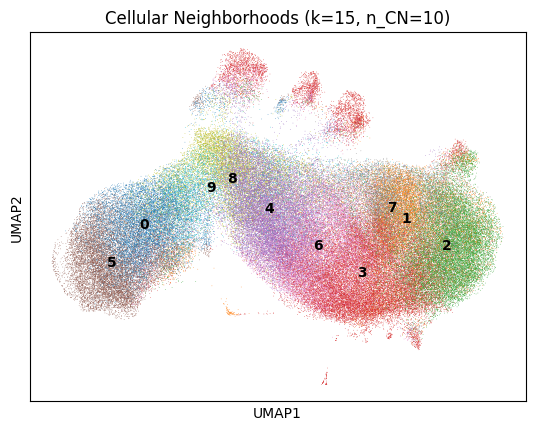

In [22]:
best_k    = int(results_df.iloc[0]['k'])
best_n_cn = int(results_df.iloc[0]['n_CN'])

print(f"Building final CN features with k={best_k}, n_CN={best_n_cn}...")

# k-NN graph
knn_best = NearestNeighbors(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_best.fit(marker_matrix)
_, indices_best = knn_best.kneighbors(marker_matrix)

# Neighborhood profiles
neighborhood_profiles_best = np.zeros_like(marker_matrix)
for i in range(len(marker_matrix)):
    neighborhood_profiles_best[i] = marker_matrix[indices_best[i]].mean(axis=0)

# CN clustering
cn_labels_best = MiniBatchKMeans(n_clusters=best_n_cn, random_state=42, n_init=3).fit_predict(neighborhood_profiles_best)
adata.obs['CN_final'] = cn_labels_best.astype(str)

# CN frequency per patient
cn_freq_final = (
    adata.obs[['patient_id', 'CN_final']]
    .groupby(['patient_id', 'CN_final'])
    .size().unstack(fill_value=0)
)
cn_freq_final = cn_freq_final.div(cn_freq_final.sum(axis=1), axis=0)
cn_freq_final.columns = [f'CN{c}_freq' for c in cn_freq_final.columns]
cn_freq_final.index = cn_freq_final.index.map(normalize_cell_id)

# Final feature matrix: cell type frequencies + CN frequencies
feature_matrix_final = pd.concat([cluster_freq, cn_freq_final], axis=1)

print(f"Final feature matrix: {feature_matrix_final.shape}")
print(f"  Cell type features : {cluster_freq.shape[1]}")
print(f"  CN features        : {cn_freq_final.shape[1]}")

# UMAP visualization of final CNs
sc.pl.umap(adata, color='CN_final', title=f'Cellular Neighborhoods (k={best_k}, n_CN={best_n_cn})',
           legend_loc='on data', legend_fontsize=10)

## 5. Survival Prediction — Cox PH Model

### 5.1 Final evaluation

Compare three conditions using Cox Proportional Hazards model with ElasticNet regularization  
and Leave-One-Out Cross-Validation (LOO-CV, n=28).

| Condition | Description |
|-----------|-------------|
| (a2) FlowSOM | RAPID paper's original method |
| (a) Leiden   | RAPID approach with Leiden clustering |
| (b) CN-Aug   | Our method: Leiden + Cellular Neighborhood features |

In [23]:
print("Running final evaluation (LOO-CV)...\n")

scores_fs,      ci_fs,      ibs_fs,      auc_fs      = run_loocv_full(flowsom_freq,       "Condition (a2) — FlowSOM Baseline")
scores_a_final, ci_a_final, ibs_a_final, auc_a_final = run_loocv_full(cluster_freq,       "Condition (a)  — Leiden Baseline")
scores_b_final, ci_b_final, ibs_b_final, auc_b_final = run_loocv_full(feature_matrix_final, f"Condition (b)  — CN-Augmented (k={best_k}, n_CN={best_n_cn})")

print(f"\n{'='*60}")
print(f"{'Metric':<30} {'FlowSOM':>9} {'Leiden':>9} {'CN-Aug':>9}")
print(f"{'-'*60}")
print(f"{'C-index':<30} {ci_fs:>9.4f} {ci_a_final:>9.4f} {ci_b_final:>9.4f}")
print(f"{'Integrated Brier Score':<30} {ibs_fs:>9.4f} {ibs_a_final:>9.4f} {ibs_b_final:>9.4f}")
print(f"{'AUC at 300 days':<30} {auc_fs[0]:>9.4f} {auc_a_final[0]:>9.4f} {auc_b_final[0]:>9.4f}")
print(f"{'AUC at 600 days':<30} {auc_fs[1]:>9.4f} {auc_a_final[1]:>9.4f} {auc_b_final[1]:>9.4f}")
print(f"\nNote: C-index > 0.7 is generally considered a good model.")
print(f"      Integrated Brier Score < 0.25 (random baseline).")

Running final evaluation (LOO-CV)...


Condition (a2) — FlowSOM Baseline
  C-index                : 0.6497
  Integrated Brier Score : 0.1688  (lower is better, 0.25 = random)
  AUC at 300 days        : 0.5882
  AUC at 600 days        : 0.7063

Condition (a)  — Leiden Baseline
  C-index                : 0.6016
  Integrated Brier Score : 0.1842  (lower is better, 0.25 = random)
  AUC at 300 days        : 0.5508
  AUC at 600 days        : 0.5813

Condition (b)  — CN-Augmented (k=15, n_CN=10)
  C-index                : 0.7005
  Integrated Brier Score : 0.1548  (lower is better, 0.25 = random)
  AUC at 300 days        : 0.6738
  AUC at 600 days        : 0.6937

Metric                           FlowSOM    Leiden    CN-Aug
------------------------------------------------------------
C-index                           0.6497    0.6016    0.7005
Integrated Brier Score            0.1688    0.1842    0.1548
AUC at 300 days                   0.5882    0.5508    0.6738
AUC at 600 days               

### 5.2 Save risk scores for Experiment 2

In [24]:
# Risk scores are passed to the teammate for Kaplan-Meier analysis (Experiment 2)
risk_score_df = pd.DataFrame({
    'patient_id'      : cluster_freq.index.tolist(),
    'OS.Time'         : clinical_indexed.loc[cluster_freq.index, 'OS.Time'].values,
    'OS.Status'       : clinical_indexed.loc[cluster_freq.index, 'OS.Status'].values,
    'risk_score_RAPID': scores_a_final,
    'risk_score_CN'   : scores_b_final
})

risk_score_df.to_csv('./risk_scores_for_KM.csv', index=False)
print("Saved: risk_scores_for_KM.csv")
print()
print(risk_score_df.round(4).to_string(index=False))

Saved: risk_scores_for_KM.csv

patient_id  OS.Time  OS.Status  risk_score_RAPID  risk_score_CN
       K01      364          1           -0.6984        -0.5834
      LC18      240          1           -0.1538         0.0433
      LC21      267          1            0.1618         0.0413
      LC27      252          1           -0.4034        -0.1412
      LC02       53          1            0.3302         0.6524
      LC03       57          1            0.2074         0.1349
      LC04      918          1           -0.1163        -0.3284
      LC06     1588          0           -0.5146        -2.5970
      LC08      441          1            0.2431         0.2422
      LC09      110          1           -0.2177         0.2663
      LC10      178          1            0.4378         0.4201
      LC11      411          1            0.2371         0.4502
      LC12      710          1            0.6751         0.8854
      LC22      366          1           -0.3392        -0.0394
      LC2

### 5.3 Survival Analysis

In [25]:
data_dir_surv = './data/fcs_files/GBM Survival Data.csv'
survival_data = pd.read_csv(data_dir_surv)

survival_data.columns = survival_data.columns.str.strip()

print("Survival data columns:")
print(survival_data.columns.tolist())
print()
print(survival_data.head())

risk_score_df = pd.DataFrame({
    "patient_id": cluster_freq.index.tolist(),
    "risk_score_RAPID": scores_a_final,
    "risk_score_CN": scores_b_final
})

print("\nRisk score dataframe:")
print(risk_score_df.head())

km_df = risk_score_df.merge(
    survival_data[["Patient.ID", "OS.Time", "OS.Status"]],
    left_on="patient_id",
    right_on="Patient.ID",
    how="inner"
).drop(columns=["Patient.ID"])

print("\nMerged dataframe for KM:")
print(km_df.head())
print(f"\nNumber of matched patients: {km_df.shape[0]}")

Survival data columns:
['Patient.ID', 'PFS.Time', 'OS.Time', 'OS.Status', 'PFS.Status']

  Patient.ID  PFS.Time  OS.Time  OS.Status  PFS.Status
0       LC10       117      178          1           0
1       LC11       111      411          1           1
2       LC12       606      710          1           1
3        W12       190      723          1           1
4         W4       220      456          1           1

Risk score dataframe:
  patient_id  risk_score_RAPID  risk_score_CN
0        K01         -0.698438      -0.583394
1       LC18         -0.153794       0.043339
2       LC21          0.161790       0.041277
3       LC27         -0.403355      -0.141220
4       LC02          0.330175       0.652394

Merged dataframe for KM:
  patient_id  risk_score_RAPID  risk_score_CN  OS.Time  OS.Status
0        K01         -0.698438      -0.583394      364          1
1       LC18         -0.153794       0.043339      240          1
2       LC21          0.161790       0.041277      267    

### 5.3.1 Helper functions

In [26]:
def run_km_experiment(df, score_col, time_col="OS.Time", event_col="OS.Status"):

    work_df = df[[score_col, time_col, event_col]].dropna().copy()

    # Ensure numeric
    work_df[time_col] = pd.to_numeric(work_df[time_col], errors="coerce")
    work_df[event_col] = pd.to_numeric(work_df[event_col], errors="coerce")
    work_df[score_col] = pd.to_numeric(work_df[score_col], errors="coerce")
    work_df = work_df.dropna()

    # Median split
    cutoff = work_df[score_col].median()
    work_df["risk_group"] = work_df[score_col].apply(
        lambda x: "High risk" if x >= cutoff else "Low risk"
    )

    low_df = work_df[work_df["risk_group"] == "Low risk"]
    high_df = work_df[work_df["risk_group"] == "High risk"]

    # Fit KM curves
    kmf_low = KaplanMeierFitter()
    kmf_high = KaplanMeierFitter()

    plt.figure(figsize=(7, 5))

    kmf_low.fit(
        durations=low_df[time_col],
        event_observed=low_df[event_col],
        label=f"Low risk (n={len(low_df)})"
    )
    kmf_low.plot_survival_function(ci_show=True)

    kmf_high.fit(
        durations=high_df[time_col],
        event_observed=high_df[event_col],
        label=f"High risk (n={len(high_df)})"
    )
    kmf_high.plot_survival_function(ci_show=True)

    # Log-rank test
    lr = logrank_test(
        low_df[time_col],
        high_df[time_col],
        event_observed_A=low_df[event_col],
        event_observed_B=high_df[event_col]
    )

    plt.title(
        f"Kaplan-Meier Curve ({score_col})\n"
        f"Median cutoff = {cutoff:.4f}, log-rank p = {lr.p_value:.4g}"
    )
    plt.xlabel("Overall Survival Time")
    plt.ylabel("Survival Probability")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("=" * 60)
    print(f"Score column        : {score_col}")
    print(f"Median cutoff       : {cutoff:.6f}")
    print(f"Low-risk patients   : {len(low_df)}")
    print(f"High-risk patients  : {len(high_df)}")
    print(f"Log-rank statistic  : {lr.test_statistic:.6f}")
    print(f"Log-rank p-value    : {lr.p_value:.6g}")

    return {
        "score_col": score_col,
        "cutoff": cutoff,
        "n_low": len(low_df),
        "n_high": len(high_df),
        "test_statistic": lr.test_statistic,
        "p_value": lr.p_value,
        "df": work_df
    }


### 5.3.2 Results (KP curve)

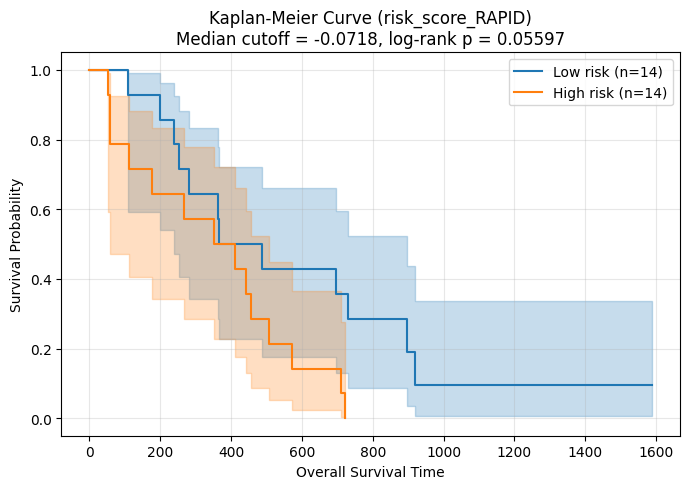

Score column        : risk_score_RAPID
Median cutoff       : -0.071812
Low-risk patients   : 14
High-risk patients  : 14
Log-rank statistic  : 3.653027
Log-rank p-value    : 0.0559674


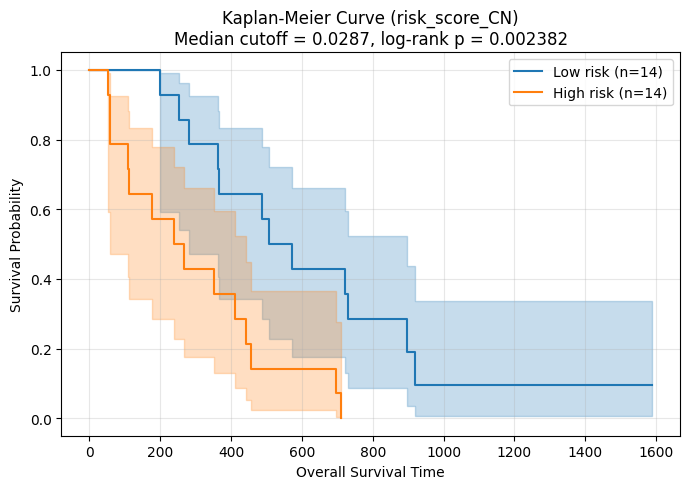

Score column        : risk_score_CN
Median cutoff       : 0.028696
Low-risk patients   : 14
High-risk patients  : 14
Log-rank statistic  : 9.229024
Log-rank p-value    : 0.00238209


In [27]:
result_rapid = run_km_experiment(km_df, "risk_score_RAPID")
result_cn = run_km_experiment(km_df, "risk_score_CN")